In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)


In [3]:
dataset = pd.read_csv("spam_ham_6.csv")
dataset.head()


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [5]:
dataset = dataset.drop(columns=['Unnamed: 0'])


In [7]:
X = dataset['text']        # Email text
y = dataset['label_num']  # 0 = ham, 1 = spam


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)



In [13]:
classifier = MultinomialNB()
classifier.fit(X_train_vec, y_train)


MultinomialNB()

In [15]:
y_pred = classifier.predict(X_test_vec)


In [17]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[909,  14],
       [ 20, 350]])

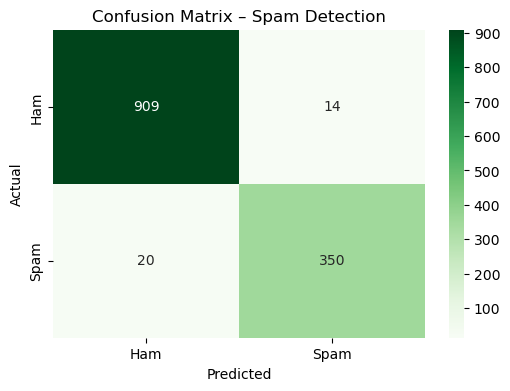

In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Spam Detection")
plt.show()


In [21]:
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.9737045630317092

In [23]:
error_rate = 1 - accuracy
error_rate


0.026295436968290842

In [25]:
precision = precision_score(y_test, y_pred)
precision


0.9615384615384616

In [27]:
recall = recall_score(y_test, y_pred)
recall


0.9459459459459459

In [29]:
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98       923
        Spam       0.96      0.95      0.95       370

    accuracy                           0.97      1293
   macro avg       0.97      0.97      0.97      1293
weighted avg       0.97      0.97      0.97      1293

